# Linear Regression

## Coefficient of Determination, denoted as $R^2$
$$ \overline{y}=\frac{1}{n}\sum\limits_{i=1}^ny_i $$
$$ SS_{res}=\sum\limits_{i}(y_i-f_i)^2=\sum\limits_ie_i^2 $$
$$ SS_{tot}=\sum\limits_{i}(y_i-\overline{y})^2 $$
$$ R^2=1-\frac{SS_{res}}{SS_{tot}} $$

## Mean Squared Error, denoted as MSE: (The Cost Function without Regularization)
$$ MSE=\frac{1}{2m}\sum\limits_{i=1}^m(h_{\theta}(x^{(i)})-y^{(i)})^2 $$

## Cost Function with Regularization
$$ J(\theta)=\frac{1}{2m}\left[\sum\limits_{i=1}^m(h_{\theta}(x^{(i)})-y^{(i)})^2+\lambda\sum\limits_{j=1}^n\theta_j^2\right] $$

## Gradient Descent Algorithm
Repeat until convergence:
$$ \theta_j := \theta_j - \alpha\frac{\partial}{\partial\theta_j}J(\theta_0,\theta_1,...,\theta_n) $$
Note: Must simultaneously update $\theta_0$ and $\theta_1$ for $j=0$, $j=1$,..., and $j=n$



If you don't know how to calculate the derivatives of $\frac{\partial}{\partial\theta_j}J(\theta_0,\theta_1)$, here are the formulas:
Repeat until convergence:
$$ \theta_0 := \theta_0 - \alpha\frac{1}{m}\sum\limits_{i=1}^m(h_\theta(x^{(i)}-y^{(i)})) $$
$$ \theta_1 := \theta_1 - \alpha\frac{1}{m}\sum\limits_{i=1}^m(h_\theta(x^{(i)}-y^{(i)}))\cdot x^{(i)} $$
Note: Must simultaneously update $\theta_0$ and $\theta_1$ for $j=0$, $j=1$,..., and $j=n$

## Normal Equation
$$ \theta = (X^TX)^{-1}X^Ty $$

In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# make an artifical dataset
x1 = np.arange(10)
np.random.seed(42)
y = 4+3*x1+2*np.random.randn(10)

ones = np.ones((10,1))

x1 = x1.reshape(10,1)

Y = y.reshape(10,1)
X = np.hstack((ones,x1))

In [2]:
# save data for future use
data = np.hstack((x1,Y))
np.savetxt('data/lin_reg_data.csv',data,delimiter=',',header='x1,y')

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv('data/lin_reg_data.csv')
df.rename(columns={'# x1':'x1'},inplace=True)
x1 = df['x1'].to_numpy().reshape(10,1)
Y = df['y'].to_numpy().reshape(10,1)
ones = np.ones((10,1))
X = np.hstack((ones,x1))

In [5]:
w

array([[10.],
       [10.]])

In [14]:
w=np.array([100,10],dtype=float).reshape(2,1)
alpha = 0.03 # learning rate

iter = []
cost1 = []
cost2 = []
m = 0

No. of iterations:  517 , Theta values:  [[6.08487521]
 [2.80652711]] ,  MSE =  3.0930621741211417 , R2 =  0.9702072238936063


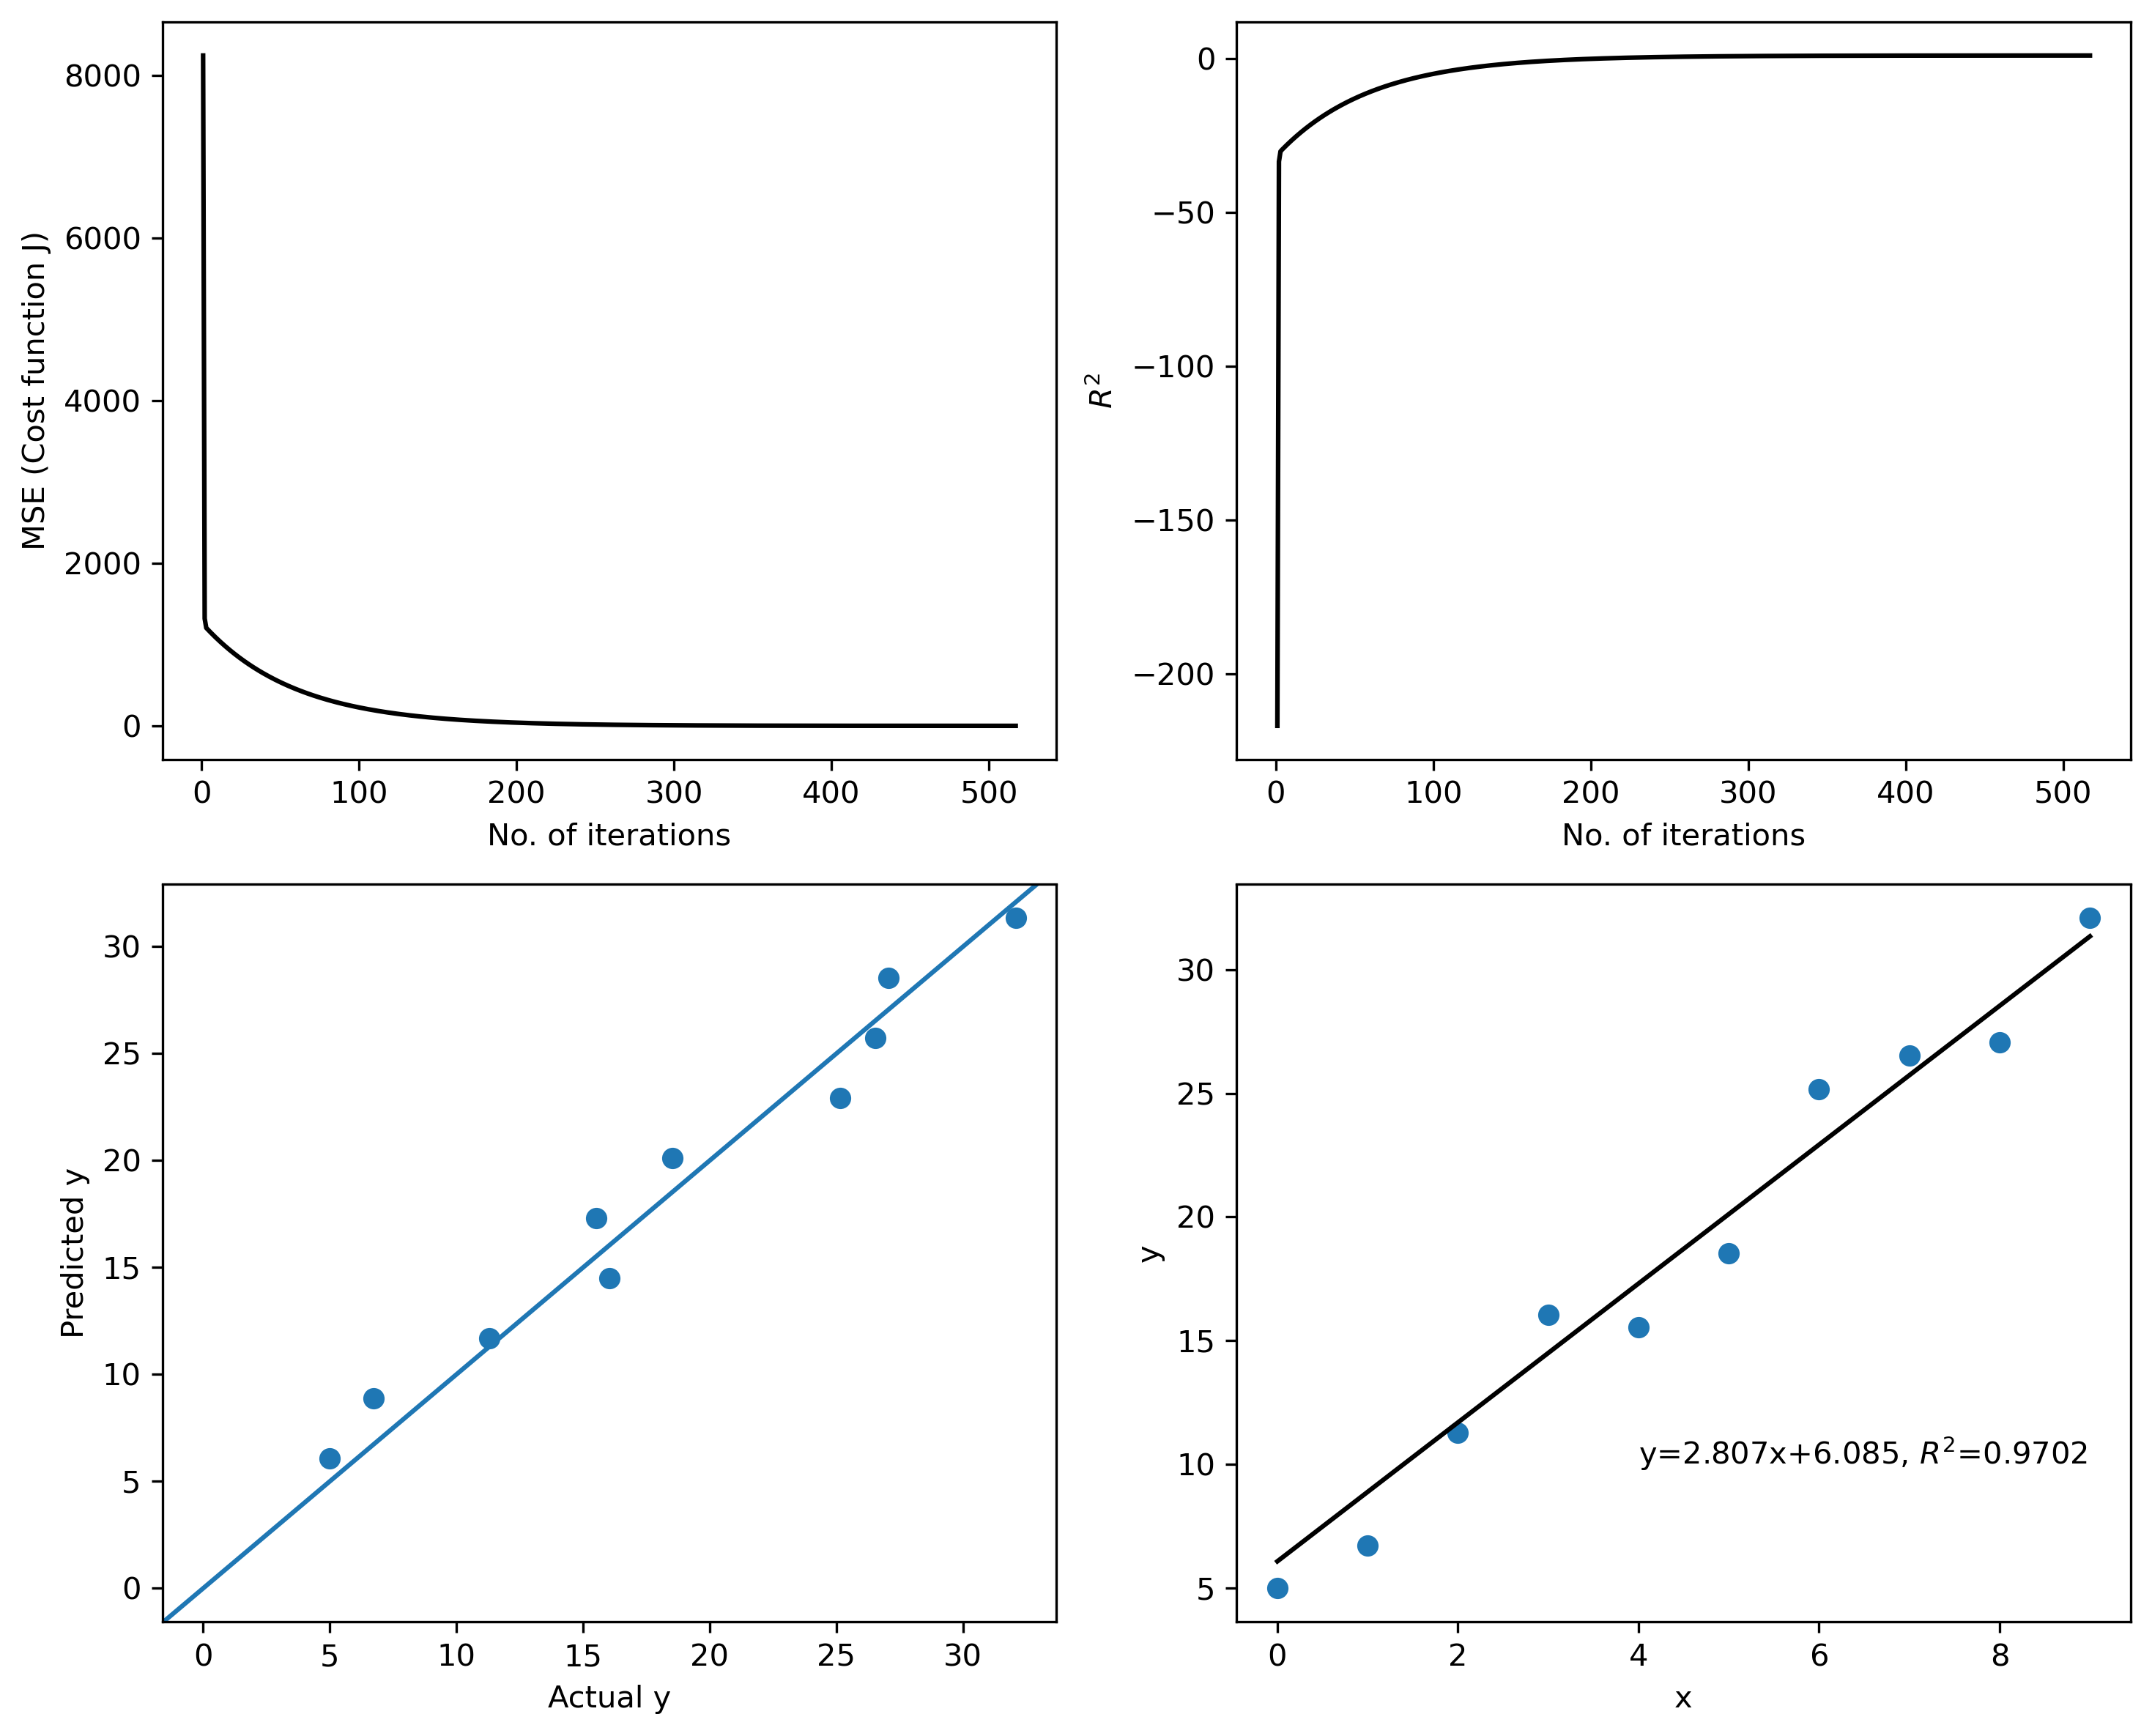

In [15]:
while True:
    H = X@w

    mse = (np.sum((H-Y)**2)+lam*np.sum(w[1:,:]**2))/(2*H.shape[0])
    r2=1-np.sum((Y-H)**2)/np.sum((Y-np.mean(Y))**2)

    if m>1 and cost1[-1]-mse<0.001:
        break

    temp0 = w[0,0] - alpha*(1/len(H))*np.sum(H-Y)
    temp1 = w[1,0] - alpha*(1/len(H))*np.sum((H-Y)*x1)
    w[0,0] = temp0
    w[1,0] = temp1

    m += 1
    iter.append(m)
    cost1.append(mse)
    cost2.append(r2)

fig = plt.figure(figsize=(10,8),dpi=300)
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)
ax1.plot(iter,cost1,'k-',label='MSE')
ax2.plot(iter,cost2,'k-',label=f'$R^2$')
ax3.scatter(Y,H)
ax3.axline([0, 0], [1, 1])
ax4.scatter(x1,Y)
ax4.plot(x1,(w[0,0]+w[1,0]*x1),'k-')
ax4.text(4,10,f'y={w[1,0]:.3f}x+{w[0,0]:.3f}, $R^2$={r2:.4f}')

ax1.set_xlabel('No. of iterations')
ax1.set_ylabel('MSE (Cost function J)')
ax2.set_xlabel('No. of iterations')
ax2.set_ylabel(f'$R^2$')
ax3.set_xlabel('Actual y')
ax3.set_ylabel('Predicted y')
ax4.set_xlabel('x')
ax4.set_ylabel('y')
plt.tight_layout()

print('No. of iterations: ', m,',', 'Theta values: ',w,', ','MSE = ',mse,',', 'R2 = ',r2)



Theta values:  [[4.95822557]
 [2.98619926]] ,  MSE:  9.315494938031147 ,  R2 value:  0.975078487642446


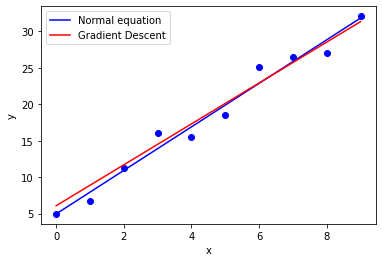

In [11]:
# Normal equation

w1=np.linalg.inv(X.T@X)@(X.T)@Y
H1=X@w1
mse1 = (np.sum((H1-Y)**2)+lam*np.sum(w1**2))/(2*H.shape[0])
r21=1-np.sum((Y-H1)**2)/np.sum((Y-np.mean(Y))**2)
print('Theta values: ',w1,', ','MSE: ',mse1,', ','R2 value: ',r21)
plt.scatter(x1,Y,color='b')
plt.plot(x1,(w1[0,0]+w1[1,0]*x1),'b-',label='Normal equation')
plt.plot(x1,(w[0,0]+w[1,0]*x1),'r-',label='Gradient Descent')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='best')
#plt.axline([0, 0], [1, 1])

In [43]:
w1

array([[4.95822557],
       [2.98619926]])